In [ ]:
# Factory Reallocation & Shipping Optimization Recommendation System
## Notebook 1: Data Preparation & Feature Engineering

### Objective
#This notebook prepares the Nassau Candy shipment dataset for machine learning by performing data cleaning, preprocessing, feature engineering, encoding, scaling, and quality validation. The processed dataset generated in this notebook will be used in subsequent stages including exploratory data analysis, lead time prediction, route clustering, factory reallocation, and recommendation generation.

In [1]:
# ==========================================================
# Import Required Libraries
# ==========================================================

import warnings
warnings.filterwarnings('ignore')

# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Date & Time
from datetime import datetime

# Preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# Display Settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 10)

# Plot Style
plt.style.use('ggplot')

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
# ==========================================================
# Load Datasets
# ==========================================================

orders = pd.read_csv("datasets/orders.csv")

factory = pd.read_csv("datasets/factory_master.csv")

product_factory = pd.read_csv("datasets/product_factory_mapping.csv")

region = pd.read_csv("datasets/region_master.csv")

print("Datasets loaded successfully.")

Datasets loaded successfully.


In [4]:
# Preview Orders Dataset

orders.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost,Factory,Factory Latitude,Factory Longitude,Distance (km),Lead Time
0,1,ORD00001,2025-02-07,2025-02-08,Same Day,CUST9313,USA,Houston,TX,38140,Sugar,South,P138,Laffy Taffy,763.73,284,270.90,492.83,Sugar Shack,48.119140,-96.181150,297,1
1,2,ORD00002,2025-05-04,2025-05-05,Same Day,CUST3028,USA,Chicago,IL,39260,Chocolate,Central,P745,Wonka Bar - Fudge Mallows,199.10,56,37.95,161.15,Lot's O' Nuts,32.881893,-111.768036,386,1
2,3,ORD00003,2025-04-24,2025-04-25,Same Day,CUST7867,USA,New York,NY,28907,Sugar,East,P653,Everlasting Gobstopper,122.13,33,26.71,95.42,Secret Factory,41.446333,-90.565487,303,1
3,4,ORD00004,2025-10-25,2025-10-29,Second,CUST2028,USA,Los Angeles,CA,83972,Chocolate,West,P161,Wonka Bar - Fudge Mallows,393.92,106,136.23,257.69,Lot's O' Nuts,32.881893,-111.768036,522,4
4,5,ORD00005,2025-08-07,2025-08-12,Same Day,CUST6924,USA,Houston,TX,49291,Other,South,P354,Fizzy Lifting Drinks,794.38,170,341.50,452.88,Sugar Shack,48.119140,-96.181150,2277,5


In [5]:
print("="*50)
print("Orders Dataset Shape")
print("="*50)

print(f"Rows    : {orders.shape[0]}")
print(f"Columns : {orders.shape[1]}")

Orders Dataset Shape
Rows    : 5000
Columns : 23


In [6]:
orders.info()
factory.info()
product_factory.info()
region.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Row ID             5000 non-null   int64  
 1   Order ID           5000 non-null   str    
 2   Order Date         5000 non-null   str    
 3   Ship Date          5000 non-null   str    
 4   Ship Mode          5000 non-null   str    
 5   Customer ID        5000 non-null   str    
 6   Country/Region     5000 non-null   str    
 7   City               5000 non-null   str    
 8   State/Province     5000 non-null   str    
 9   Postal Code        5000 non-null   int64  
 10  Division           5000 non-null   str    
 11  Region             5000 non-null   str    
 12  Product ID         5000 non-null   str    
 13  Product Name       5000 non-null   str    
 14  Sales              5000 non-null   float64
 15  Units              5000 non-null   int64  
 16  Gross Profit       5000 non-null   

In [7]:
orders.describe()
factory.describe()
product_factory.describe()
region.describe()

,Region,State,City
count,4,4,4
unique,4,4,4
top,East,NY,New York
freq,1,1,1


In [15]:
orders.dtypes


Row ID                 int64
Order ID                 str
Order Date               str
Ship Date                str
Ship Mode                str
                      ...   
Factory                  str
Factory Latitude     float64
Factory Longitude    float64
Distance (km)          int64
Lead Time              int64
Length: 23, dtype: object

In [16]:
factory.dtypes

Factory          str
Latitude     float64
Longitude    float64
dtype: object

In [17]:
product_factory.dtypes

Division        str
Product Name    str
Factory         str
dtype: object

In [18]:
region.dtypes

Region    str
State     str
City      str
dtype: object

In [11]:
orders.isnull().sum()

Row ID               0
Order ID             0
Order Date           0
Ship Date            0
Ship Mode            0
                    ..
Factory              0
Factory Latitude     0
Factory Longitude    0
Distance (km)        0
Lead Time            0
Length: 23, dtype: int64

In [12]:
factory.isnull().sum()

Factory      0
Latitude     0
Longitude    0
dtype: int64

In [13]:
product_factory.isnull().sum()

Division        0
Product Name    0
Factory         0
dtype: int64

In [14]:
region.isnull().sum()

Region    0
State     0
City      0
dtype: int64

In [19]:
# ==========================================================
# Duplicate Record Analysis
# ==========================================================

duplicate_count = orders.duplicated().sum()

print("=" * 50)
print("Duplicate Record Analysis")
print("=" * 50)

print(f"Number of Duplicate Records : {duplicate_count}")

Duplicate Record Analysis
Number of Duplicate Records : 0


In [20]:
# ==========================================================
# Memory Usage
# ==========================================================

memory = orders.memory_usage(deep=True).sum() / (1024 ** 2)

print("=" * 50)
print("Dataset Memory Usage")
print("=" * 50)

print(f"Memory Usage : {memory:.2f} MB")

Dataset Memory Usage
Memory Usage : 1.37 MB


In [21]:
memory_df = pd.DataFrame({
    "Column": orders.columns,
    "Memory (KB)": (orders.memory_usage(deep=True)[1:] / 1024).values
})

memory_df.sort_values(
    by="Memory (KB)",
    ascending=False
)

,Column,Memory (KB)
13,Product Name,125.754883
18,Factory,104.188477
2,Order Date,87.890625
3,Ship Date,87.890625
7,City,79.252930
...,...,...
16,Gross Profit,39.062500
15,Units,39.062500
14,Sales,39.062500
9,Postal Code,39.062500


In [22]:
print("=" * 50)
print("Data Types")
print("=" * 50)

orders.dtypes

Data Types


Row ID                 int64
Order ID                 str
Order Date               str
Ship Date                str
Ship Mode                str
                      ...   
Factory                  str
Factory Latitude     float64
Factory Longitude    float64
Distance (km)          int64
Lead Time              int64
Length: 23, dtype: object

In [23]:
date_columns = ['Order Date', 'Ship Date']

orders[date_columns].head()

,Order Date,Ship Date
0,2025-02-07,2025-02-08
1,2025-05-04,2025-05-05
2,2025-04-24,2025-04-25
3,2025-10-25,2025-10-29
4,2025-08-07,2025-08-12


In [24]:
orders['Order Date'] = pd.to_datetime(orders['Order Date'])

orders['Ship Date'] = pd.to_datetime(orders['Ship Date'])

print("Date conversion completed successfully.")

Date conversion completed successfully.


In [25]:
orders[['Order Date', 'Ship Date']].dtypes

Order Date    datetime64[us]
Ship Date     datetime64[us]
dtype: object

In [ ]:
#FEATURE ENGINEERING 

In [26]:
# ==========================================================
# Recalculate Lead Time
# ==========================================================

orders['Lead Time'] = (
    orders['Ship Date'] - orders['Order Date']
).dt.days

print("Lead Time recalculated successfully.")

orders[['Order Date','Ship Date','Lead Time']].head()

Lead Time recalculated successfully.


,Order Date,Ship Date,Lead Time
0,2025-02-07,2025-02-08,1
1,2025-05-04,2025-05-05,1
2,2025-04-24,2025-04-25,1
3,2025-10-25,2025-10-29,4
4,2025-08-07,2025-08-12,5


In [27]:
print("Minimum Lead Time :", orders['Lead Time'].min())
print("Maximum Lead Time :", orders['Lead Time'].max())

Minimum Lead Time : 1
Maximum Lead Time : 8


In [28]:
# ==========================================================
# Profit Margin
# ==========================================================

orders['Profit Margin (%)'] = (
    orders['Gross Profit'] /
    orders['Sales']
) * 100

orders['Profit Margin (%)'] = orders['Profit Margin (%)'].round(2)

orders[['Sales',
        'Gross Profit',
        'Profit Margin (%)']].head()

,Sales,Gross Profit,Profit Margin (%)
0,763.73,270.90,35.47
1,199.10,37.95,19.06
2,122.13,26.71,21.87
3,393.92,136.23,34.58
4,794.38,341.50,42.99


In [29]:
# ==========================================================
# Sales Per Unit
# ==========================================================

orders['Sales per Unit'] = (
    orders['Sales'] /
    orders['Units']
)

orders['Sales per Unit'] = orders['Sales per Unit'].round(2)

orders[['Units',
         'Sales',
         'Sales per Unit']].head()

,Units,Sales,Sales per Unit
0,284,763.73,2.69
1,56,199.10,3.56
2,33,122.13,3.70
3,106,393.92,3.72
4,170,794.38,4.67


In [30]:
# ==========================================================
# Cost Per Unit
# ==========================================================

orders['Cost per Unit'] = (
    orders['Cost'] /
    orders['Units']
)

orders['Cost per Unit'] = orders['Cost per Unit'].round(2)

orders[['Cost',
         'Units',
         'Cost per Unit']].head()

,Cost,Units,Cost per Unit
0,492.83,284,1.74
1,161.15,56,2.88
2,95.42,33,2.89
3,257.69,106,2.43
4,452.88,170,2.66


In [31]:
# ==========================================================
# Distance Category
# ==========================================================

bins = [0, 500, 1000, 1500, 2500]

labels = [
    'Short',
    'Medium',
    'Long',
    'Very Long'
]

orders['Distance Category'] = pd.cut(
    orders['Distance (km)'],
    bins=bins,
    labels=labels
)

orders[['Distance (km)',
         'Distance Category']].head()

,Distance (km),Distance Category
0,297,Short
1,386,Short
2,303,Short
3,522,Medium
4,2277,Very Long


In [32]:
# ==========================================================
# High Value Order Flag
# ==========================================================

sales_threshold = orders['Sales'].median()

orders['High Value Order'] = np.where(
    orders['Sales'] >= sales_threshold,
    'Yes',
    'No'
)

orders[['Sales',
         'High Value Order']].head()

,Sales,High Value Order
0,763.73,Yes
1,199.10,No
2,122.13,No
3,393.92,No
4,794.38,Yes


In [33]:
# ==========================================================
# Route ID
# ==========================================================

orders['Route ID'] = (
    orders['Factory'] + "_" +
    orders['Region']
)

orders[['Factory',
         'Region',
         'Route ID']].head()

,Factory,Region,Route ID
0,Sugar Shack,South,Sugar Shack_South
1,Lot's O' Nuts,Central,Lot's O' Nuts_Central
2,Secret Factory,East,Secret Factory_East
3,Lot's O' Nuts,West,Lot's O' Nuts_West
4,Sugar Shack,South,Sugar Shack_South


In [34]:
print("=" * 60)
print("Newly Created Features")
print("=" * 60)

new_features = [
    'Lead Time',
    'Profit Margin (%)',
    'Sales per Unit',
    'Cost per Unit',
    'Distance Category',
    'High Value Order',
    'Route ID'
]

orders[new_features].head()

Newly Created Features


,Lead Time,Profit Margin (%),Sales per Unit,Cost per Unit,Distance Category,High Value Order,Route ID
0,1,35.47,2.69,1.74,Short,Yes,Sugar Shack_South
1,1,19.06,3.56,2.88,Short,No,Lot's O' Nuts_Central
2,1,21.87,3.70,2.89,Short,No,Secret Factory_East
3,4,34.58,3.72,2.43,Medium,No,Lot's O' Nuts_West
4,5,42.99,4.67,2.66,Very Long,Yes,Sugar Shack_South


In [35]:
# ==========================================================
# Estimated Shipping Cost
# ==========================================================

shipping_rate = {
    'Standard': 0.45,
    'Second': 0.60,
    'First': 0.80,
    'Same Day': 1.10
}

# Map shipping rate
orders['Shipping Rate ($/km)'] = orders['Ship Mode'].map(shipping_rate)

# Calculate shipping cost
orders['Estimated Shipping Cost'] = (
    orders['Distance (km)'] *
    orders['Shipping Rate ($/km)']
).round(2)

print("Estimated Shipping Cost created successfully.")

orders[['Ship Mode',
         'Distance (km)',
         'Shipping Rate ($/km)',
         'Estimated Shipping Cost']].head()

Estimated Shipping Cost created successfully.


,Ship Mode,Distance (km),Shipping Rate ($/km),Estimated Shipping Cost
0,Same Day,297,1.1,326.7
1,Same Day,386,1.1,424.6
2,Same Day,303,1.1,333.3
3,Second,522,0.6,313.2
4,Same Day,2277,1.1,2504.7


In [36]:
# ==========================================================
# Delivery Efficiency Score
# ==========================================================

orders['Delivery Efficiency Score'] = (
    orders['Distance (km)'] /
    orders['Lead Time']
).round(2)

print("Delivery Efficiency Score created successfully.")

orders[['Distance (km)',
         'Lead Time',
         'Delivery Efficiency Score']].head()

Delivery Efficiency Score created successfully.


,Distance (km),Lead Time,Delivery Efficiency Score
0,297,1,297.0
1,386,1,386.0
2,303,1,303.0
3,522,4,130.5
4,2277,5,455.4


In [37]:
engineered_features = [
    'Lead Time',
    'Profit Margin (%)',
    'Sales per Unit',
    'Cost per Unit',
    'Distance Category',
    'High Value Order',
    'Route ID',
    'Estimated Shipping Cost',
    'Delivery Efficiency Score'
]

orders[engineered_features].head()

,Lead Time,Profit Margin (%),Sales per Unit,Cost per Unit,Distance Category,High Value Order,Route ID,Estimated Shipping Cost,Delivery Efficiency Score
0,1,35.47,2.69,1.74,Short,Yes,Sugar Shack_South,326.7,297.0
1,1,19.06,3.56,2.88,Short,No,Lot's O' Nuts_Central,424.6,386.0
2,1,21.87,3.70,2.89,Short,No,Secret Factory_East,333.3,303.0
3,4,34.58,3.72,2.43,Medium,No,Lot's O' Nuts_West,313.2,130.5
4,5,42.99,4.67,2.66,Very Long,Yes,Sugar Shack_South,2504.7,455.4


In [38]:
# ==========================================================
# Orders Assigned to Each Factory
# ==========================================================

factory_orders = orders.groupby('Factory').size()

factory_orders

Factory
Lot's O' Nuts         996
Secret Factory        977
Sugar Shack          1676
The Other Factory     681
Wicked Choccy's       670
dtype: int64

In [39]:
factory_orders = (
    orders.groupby('Factory')
    .size()
    .reset_index(name='Factory Order Count')
)

factory_orders

,Factory,Factory Order Count
0,Lot's O' Nuts,996
1,Secret Factory,977
2,Sugar Shack,1676
3,The Other Factory,681
4,Wicked Choccy's,670


In [40]:
orders = orders.merge(
    factory_orders,
    on='Factory',
    how='left'
)

orders.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost,Factory,Factory Latitude,Factory Longitude,Distance (km),Lead Time,Profit Margin (%),Sales per Unit,Cost per Unit,Distance Category,High Value Order,Route ID,Shipping Rate ($/km),Estimated Shipping Cost,Delivery Efficiency Score,Factory Order Count
0,1,ORD00001,2025-02-07,2025-02-08,Same Day,CUST9313,USA,Houston,TX,38140,Sugar,South,P138,Laffy Taffy,763.73,284,270.90,492.83,Sugar Shack,48.119140,-96.181150,297,1,35.47,2.69,1.74,Short,Yes,Sugar Shack_South,1.1,326.7,297.0,1676
1,2,ORD00002,2025-05-04,2025-05-05,Same Day,CUST3028,USA,Chicago,IL,39260,Chocolate,Central,P745,Wonka Bar - Fudge Mallows,199.10,56,37.95,161.15,Lot's O' Nuts,32.881893,-111.768036,386,1,19.06,3.56,2.88,Short,No,Lot's O' Nuts_Central,1.1,424.6,386.0,996
2,3,ORD00003,2025-04-24,2025-04-25,Same Day,CUST7867,USA,New York,NY,28907,Sugar,East,P653,Everlasting Gobstopper,122.13,33,26.71,95.42,Secret Factory,41.446333,-90.565487,303,1,21.87,3.70,2.89,Short,No,Secret Factory_East,1.1,333.3,303.0,977
3,4,ORD00004,2025-10-25,2025-10-29,Second,CUST2028,USA,Los Angeles,CA,83972,Chocolate,West,P161,Wonka Bar - Fudge Mallows,393.92,106,136.23,257.69,Lot's O' Nuts,32.881893,-111.768036,522,4,34.58,3.72,2.43,Medium,No,Lot's O' Nuts_West,0.6,313.2,130.5,996
4,5,ORD00005,2025-08-07,2025-08-12,Same Day,CUST6924,USA,Houston,TX,49291,Other,South,P354,Fizzy Lifting Drinks,794.38,170,341.50,452.88,Sugar Shack,48.119140,-96.181150,2277,5,42.99,4.67,2.66,Very Long,Yes,Sugar Shack_South,1.1,2504.7,455.4,1676


In [41]:
# ==========================================================
# Factory Workload Category
# ==========================================================

low = factory_orders['Factory Order Count'].quantile(0.33)
high = factory_orders['Factory Order Count'].quantile(0.66)

def workload_category(x):
    if x <= low:
        return 'Low'
    elif x <= high:
        return 'Medium'
    else:
        return 'High'

orders['Factory Workload'] = orders['Factory Order Count'].apply(workload_category)

orders[['Factory',
         'Factory Order Count',
         'Factory Workload']].head()

,Factory,Factory Order Count,Factory Workload
0,Sugar Shack,1676,High
1,Lot's O' Nuts,996,High
2,Secret Factory,977,Medium
3,Lot's O' Nuts,996,High
4,Sugar Shack,1676,High


In [42]:
orders[['Factory',
         'Factory Order Count',
         'Factory Workload']] \
      .drop_duplicates() \
      .sort_values('Factory Order Count',
                   ascending=False)

,Factory,Factory Order Count,Factory Workload
0,Sugar Shack,1676,High
1,Lot's O' Nuts,996,High
2,Secret Factory,977,Medium
8,The Other Factory,681,Low
17,Wicked Choccy's,670,Low


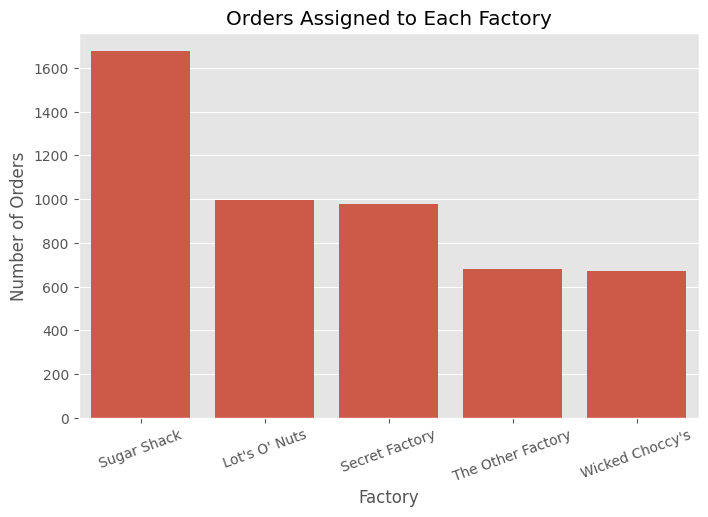

In [43]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=orders,
    x='Factory',
    order=orders['Factory'].value_counts().index
)

plt.title("Orders Assigned to Each Factory")

plt.xlabel("Factory")

plt.ylabel("Number of Orders")

plt.xticks(rotation=20)

plt.show()

In [44]:
# ==========================================================
# Numerical Columns for Outlier Detection
# ==========================================================

numerical_columns = [
    'Sales',
    'Cost',
    'Gross Profit',
    'Units',
    'Distance (km)',
    'Lead Time',
    'Estimated Shipping Cost'
]

orders[numerical_columns].head()

,Sales,Cost,Gross Profit,Units,Distance (km),Lead Time,Estimated Shipping Cost
0,763.73,492.83,270.90,284,297,1,326.7
1,199.10,161.15,37.95,56,386,1,424.6
2,122.13,95.42,26.71,33,303,1,333.3
3,393.92,257.69,136.23,106,522,4,313.2
4,794.38,452.88,341.50,170,2277,5,2504.7


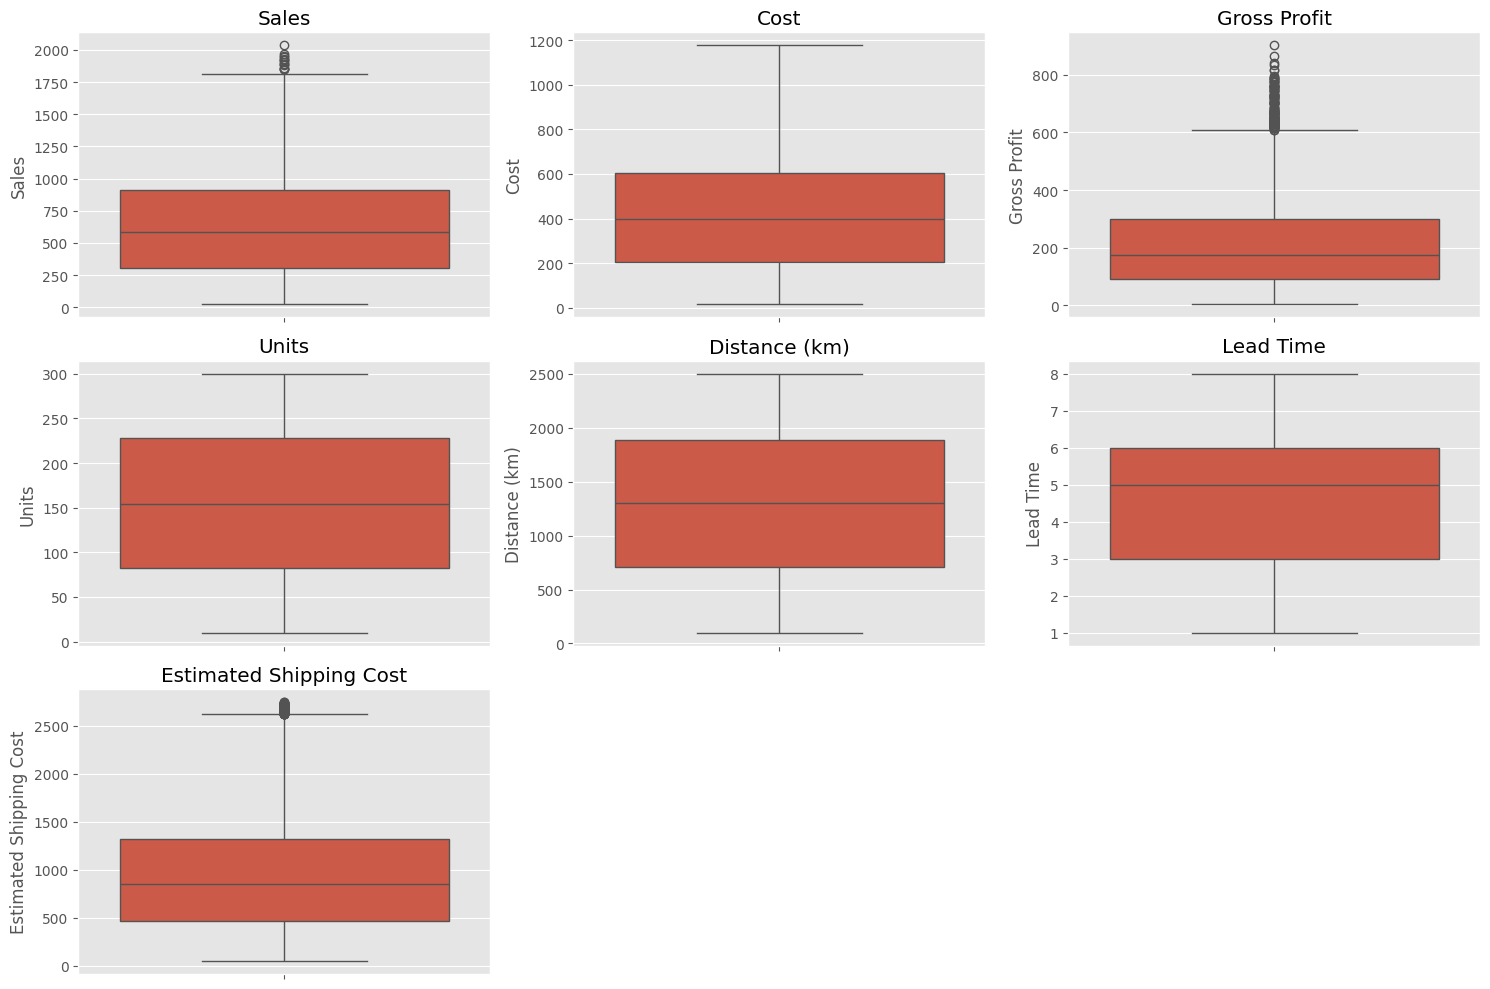

In [45]:
# ==========================================================
# Boxplots for Outlier Detection
# ==========================================================

plt.figure(figsize=(15,10))

for i, column in enumerate(numerical_columns):
    
    plt.subplot(3,3,i+1)
    
    sns.boxplot(y=orders[column])
    
    plt.title(column)

plt.tight_layout()

plt.show()

In [46]:
# ==========================================================
# Function to Detect Outliers
# ==========================================================

def detect_outliers(data, column):
    
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = data[
        (data[column] < lower) |
        (data[column] > upper)
    ]

    return len(outliers)

In [47]:
# ==========================================================
# Outlier Summary
# ==========================================================

print("="*60)
print("Outlier Summary")
print("="*60)

for column in numerical_columns:
    
    count = detect_outliers(orders, column)
    
    print(f"{column:<30} {count}")

Outlier Summary
Sales                          15
Cost                           0
Gross Profit                   132
Units                          0
Distance (km)                  0
Lead Time                      0
Estimated Shipping Cost        66


In [ ]:
# 12. Encoding Categorical Features

#Machine learning algorithms require numerical input. Therefore, categorical variables are converted into numerical representations using Label Encoding.

#The encoded features will be used for lead time prediction, route clustering, and factory recommendation models.

In [48]:
# ==========================================================
# Categorical Columns
# ==========================================================

categorical_columns = [
    'Ship Mode',
    'Division',
    'Region',
    'Factory',
    'Distance Category',
    'High Value Order',
    'Factory Workload'
]

orders[categorical_columns].head()

,Ship Mode,Division,Region,Factory,Distance Category,High Value Order,Factory Workload
0,Same Day,Sugar,South,Sugar Shack,Short,Yes,High
1,Same Day,Chocolate,Central,Lot's O' Nuts,Short,No,High
2,Same Day,Sugar,East,Secret Factory,Short,No,Medium
3,Second,Chocolate,West,Lot's O' Nuts,Medium,No,High
4,Same Day,Other,South,Sugar Shack,Very Long,Yes,High


In [49]:
# ==========================================================
# Label Encoding
# ==========================================================

from sklearn.preprocessing import LabelEncoder

label_encoders = {}

for column in categorical_columns:

    encoder = LabelEncoder()

    orders[column] = encoder.fit_transform(orders[column])

    label_encoders[column] = encoder

print("Categorical features encoded successfully.")

Categorical features encoded successfully.


In [50]:
orders[categorical_columns].head()

,Ship Mode,Division,Region,Factory,Distance Category,High Value Order,Factory Workload
0,1,2,2,2,2,1,0
1,1,0,0,0,2,0,0
2,1,2,1,1,2,0,2
3,2,0,3,0,1,0,0
4,1,1,2,2,3,1,0


In [51]:
# ==========================================================
# Display Encoding Mapping
# ==========================================================

for column, encoder in label_encoders.items():

    print("=" * 50)
    print(column)

    mapping = dict(zip(
        encoder.classes_,
        encoder.transform(encoder.classes_)
    ))

    print(mapping)

Ship Mode
{'First': np.int64(0), 'Same Day': np.int64(1), 'Second': np.int64(2), 'Standard': np.int64(3)}
Division
{'Chocolate': np.int64(0), 'Other': np.int64(1), 'Sugar': np.int64(2)}
Region
{'Central': np.int64(0), 'East': np.int64(1), 'South': np.int64(2), 'West': np.int64(3)}
Factory
{"Lot's O' Nuts": np.int64(0), 'Secret Factory': np.int64(1), 'Sugar Shack': np.int64(2), 'The Other Factory': np.int64(3), "Wicked Choccy's": np.int64(4)}
Distance Category
{'Long': np.int64(0), 'Medium': np.int64(1), 'Short': np.int64(2), 'Very Long': np.int64(3)}
High Value Order
{'No': np.int64(0), 'Yes': np.int64(1)}
Factory Workload
{'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}


In [52]:
# ==========================================================
# Numerical Features for Scaling
# ==========================================================

numerical_features = [
    'Sales',
    'Cost',
    'Gross Profit',
    'Units',
    'Distance (km)',
    'Lead Time',
    'Profit Margin (%)',
    'Sales per Unit',
    'Cost per Unit',
    'Estimated Shipping Cost',
    'Delivery Efficiency Score',
    'Factory Order Count'
]

In [53]:
# ==========================================================
# Standard Scaling
# ==========================================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

orders_scaled = orders.copy()

orders_scaled[numerical_features] = scaler.fit_transform(
    orders[numerical_features]
)

print("Feature scaling completed successfully.")

Feature scaling completed successfully.


In [54]:
orders_scaled[numerical_features].head()

,Sales,Cost,Gross Profit,Units,Distance (km),Lead Time,Profit Margin (%),Sales per Unit,Cost per Unit,Estimated Shipping Cost,Delivery Efficiency Score,Factory Order Count
0,0.307037,0.257094,0.357313,1.537084,-1.453889,-2.044175,0.373504,-1.205229,-1.399692,-1.011275,0.146644,1.339767
1,-1.085342,-1.006710,-1.102076,-1.175131,-1.324747,-2.044175,-1.688025,-0.469590,0.196314,-0.854880,0.947547,-0.339995
2,-1.275150,-1.257162,-1.172493,-1.448732,-1.445183,-2.044175,-1.335015,-0.351211,0.210314,-1.000731,0.200637,-0.386929
3,-0.604915,-0.638863,-0.486370,-0.580347,-1.127407,-0.334045,0.261697,-0.334300,-0.433688,-1.032841,-1.351674,-0.339995
4,0.382620,0.104872,0.799608,0.180976,1.419159,0.235998,1.318215,0.468984,-0.111687,2.468082,1.572071,1.339767


In [56]:
orders_scaled.to_csv(
    "datasets/processed_orders_scaled.csv",
    index=False
)

In [57]:
# ==========================================================
# Save Processed Dataset
# ==========================================================

orders.to_csv(
    "datasets/processed_orders.csv",
    index=False
)

print("Processed dataset saved successfully!")

Processed dataset saved successfully!


In [58]:
print(orders.columns.tolist())

['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Country/Region', 'City', 'State/Province', 'Postal Code', 'Division', 'Region', 'Product ID', 'Product Name', 'Sales', 'Units', 'Gross Profit', 'Cost', 'Factory', 'Factory Latitude', 'Factory Longitude', 'Distance (km)', 'Lead Time', 'Profit Margin (%)', 'Sales per Unit', 'Cost per Unit', 'Distance Category', 'High Value Order', 'Route ID', 'Shipping Rate ($/km)', 'Estimated Shipping Cost', 'Delivery Efficiency Score', 'Factory Order Count', 'Factory Workload']
